# First-order local uncertainty for a surface mechanism

## With and without correlations through BEEF-vdW DFT ensemble


**Uncorrelated Analysis:**

The uncorrelated first-order local variance $(\Delta \ln c_i)^2$, for the concentration of species $i$ is:

$$(\Delta \ln c_i)^2 = \sum_{\mathrm{reactions}\; m} \left(\frac{\partial\ln c_i}{\partial\ln k_m}\right)^2 (\Delta \ln k_m)^2  + \sum_{\mathrm{species}\; n} \left(\frac{\partial\ln c_i}{\partial G_n}\right)^2(\Delta G_n)^2$$

We can get the derivatives $\frac{\partial\ln c_i}{\partial\ln k_m}$ and $\frac{\partial\ln c_i}{\partial G_n}$ through sensitivity analysis.

We compute the input uncertainties $\Delta G_n$ and $\Delta \ln k_m$ by looking up the parameter source and adding the uncertainty that corresponds to that method. See the local_uncertainty.ipynb example or [Gao CW, Liu M, Green WH. Uncertainty analysis of correlated parameters in automated reaction mechanism generation. International journal of chemical kinetics. 2020;52(4):266-282. doi:10.1002/kin.21348](https://onlinelibrary.wiley.com/doi/10.1002/kin.21348) for more information.


**Correlated Analysis:**

The correlated first-order local variance $(\Delta \ln c_i)^2$, for the concentration of species $i$ is:

$$(\Delta \ln x)^2 = \sum_w \sum_{w'} \left(\sum_m \frac{\partial \ln x}{\partial \ln k_m} \frac{\partial \ln k_m}{\partial q_w} + \sum_n \frac{\partial \ln x}{\partial G_n} \frac{\partial G_n}{\partial q_w}\right) \Sigma_{ww'} \left(\sum_{m'} \frac{\partial \ln x}{\partial \ln k_{m'}} \frac{\partial \ln k_{m'}}{\partial q_{w'}} + \sum_{n'} \frac{\partial \ln x}{\partial G_{n'}} \frac{\partial G_{n'}}{\partial q_{w'}}\right)$$

Here, we utilize underlying input parameters $q_w$ which may be correlated to each other. For example, species thermo libraries computed using BEEF-vdW have known correlations through the DFT ensemble.

These covariances are computed and saved in the covariance matrix $\Sigma_{ww'}$.

The derivatives $\frac{\partial\ln c_i}{\partial\ln k_m}$ and $\frac{\partial\ln c_i}{\partial G_n}$ are computed through sensitivity analysis, same as the uncorrelated analysis. 

Finally, the derivatives $\frac{\partial\ln k_m}{\partial q_w}$ and $\frac{\partial\ln G_n}{\partial q_w}$ describe the weight of each underlying parameter's contribution to a particular species Gibbs energy or reaction rate, and these are tallied up by the uncertainty tool.

In [1]:
import os
import numpy as np
import subprocess

from IPython.display import display, Image

import rmgpy
from rmgpy.tools.uncertainty import Uncertainty, process_local_results
from rmgpy.tools.canteramodel import get_rmg_species_from_user_species
from rmgpy.species import Species

import cantera as ct

import logging
logging.basicConfig()
logging.getLogger().setLevel(logging.ERROR)

import matplotlib.pyplot as plt
%matplotlib inline

## 1. Load the mechanism (CH4 + O2 over Pt111) and reactor settings

In [2]:
# This is a mechanism of methane partial oxidation over Pt111

# Must use annotated chemkin file
chemkin_file = 'data/cpox_methane/chem_annotated-gas.inp'
surface_chemkin_file = 'data/cpox_methane/chem_annotated-surface.inp'
dict_file = 'data/cpox_methane/species_dictionary.txt'

# Initialize the Uncertainty class instance and load the model
uncertainty = Uncertainty(output_directory='./temp/surface_uncertainty')
uncertainty.load_model(chemkin_file, dict_file, surface_path=surface_chemkin_file)

# Map the species to the objects within the Uncertainty class
methane = Species().from_smiles('C')
X = Species().from_smiles('*')  # surface site
Ar = Species().from_smiles('[Ar]')
O2 = Species().from_smiles('[O][O]')
H2O = Species().from_smiles('O')
CO2 = Species().from_smiles('O=C=O')
mapping = get_rmg_species_from_user_species([methane, O2, H2O, CO2, Ar, X], uncertainty.species_list)

# Define the reaction conditions
initial_mole_fractions = {mapping[methane]: 0.1, mapping[Ar]: 0.8, mapping[O2]: 0.1}
initial_surface_coverage = {mapping[X]: 1.0}
T = (800, 'K')
P = (1, 'atm')
termination_time = (1.0, 's')
surface_volume_ratio = (1e5, 'm^-1')
surface_site_density = (2.4830E-09, 'mol/(cm^2)')

# Pick the species to do sensitivity analysis for (which output concentrations to analyze)
sensitive_species=[mapping[methane], mapping[CO2]]

## 2. Run Sensitivity Analysis
This computes the derivatives $\frac{\partial \ln c_i}{\partial G_n}$ and $\frac{\partial \ln c_i}{\partial \ln k_m}$ for every input species Gibbs energy $G_n$ and reaction rate $\ln k_m$ in the mechanism with respect to each sensitive species concentration $c_i$

These sensitivities will be used later to propagate the uncertain inputs through the model.

In [3]:
# Perform the sensitivity analysis- this takes ~30 seconds
uncertainty.sensitivity_analysis(
    initial_mole_fractions,
    sensitive_species,
    T,
    P,
    termination_time,
    number=5,
    fileformat='.png',
    initial_surface_coverages=initial_surface_coverage,
    surface_volume_ratio=surface_volume_ratio,
    surface_site_density=surface_site_density,
)

CH4(2): Reaction Sensitivities


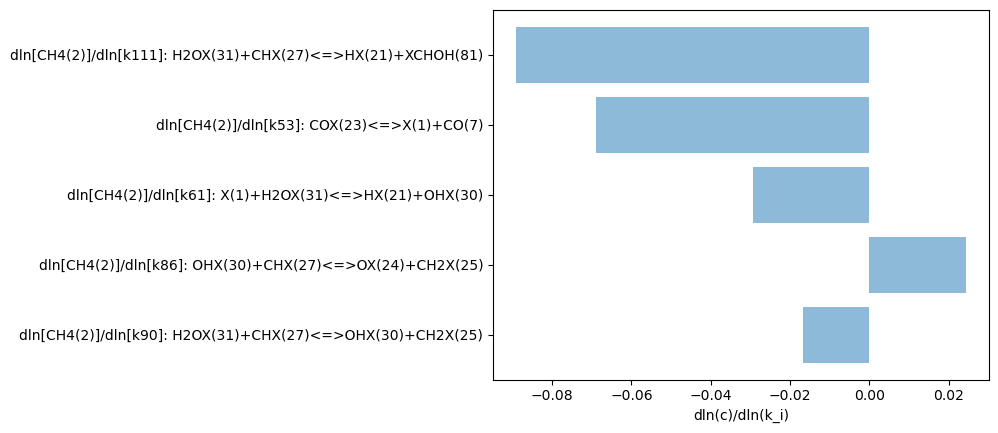

CH4(2): Thermo Sensitivities


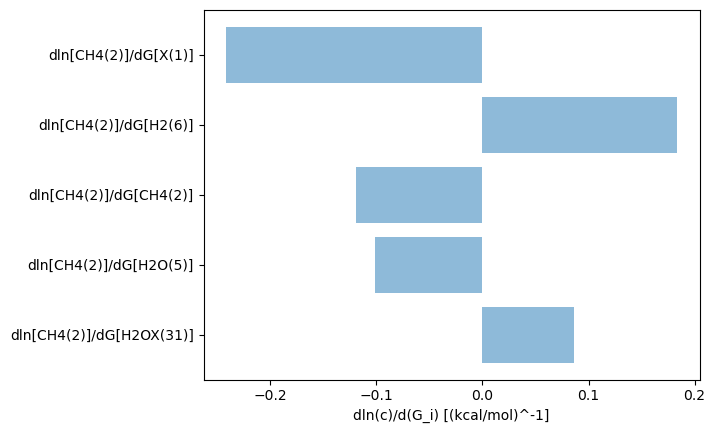

CO2(4): Reaction Sensitivities


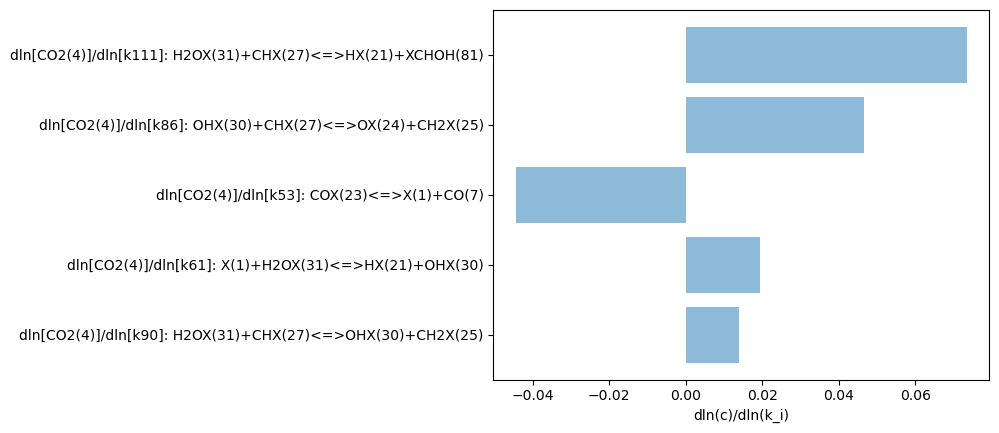

CO2(4): Thermo Sensitivities


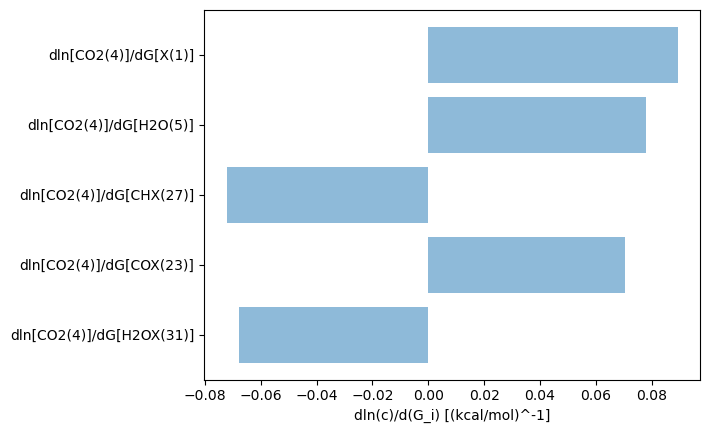

In [4]:
# Show the sensitivity plots
for species in sensitive_species:
    print('{}: Reaction Sensitivities'.format(species))
    index = species.index
    display(Image(filename=os.path.join(uncertainty.output_directory,'solver','sensitivity_1_SPC_{}_reactions.png'.format(index))))
    
    print('{}: Thermo Sensitivities'.format(species))
    display(Image(filename=os.path.join(uncertainty.output_directory,'solver','sensitivity_1_SPC_{}_thermo.png'.format(index))))

## 3. Assign (Uncorrelated) Parameter Uncertainties

Here we look up the sources used to compute each parameter and assign a value for $\Delta G_n$ or $\Delta \ln k_m$

### Load the same database that's used in the RMG input file

In [5]:
uncertainty.load_database(
    thermo_libraries=['surfaceThermoPt111', 'primaryThermoLibrary', 'thermo_DFT_CCSDTF12_BAC', 'DFT_QCI_thermo'],
    kinetics_families=['default', 'surface'],
    reaction_libraries=['Surface/CPOX_Pt/Deutschmann2006_adjusted', 'BurkeH2O2inArHe'],
)

### Assign input parameter uncertainties according to their sources

In [6]:
# reset the correlated libraries/groups back to the uncorrelated defaults in case someone runs the cells out of order
uncertainty.thermo_covariance_libraries = None  # default is None
uncertainty.thermo_covariance_groups = None  # these are the defaults

uncertainty.extract_sources_from_model()
uncertainty.assign_intermediate_uncertainties(correlated=False)

# Save the covariance matrix for later comparison
uncorrelated_thermo_cov = uncertainty.get_thermo_covariance_matrix()
uncorrelated_kinetics_cov = uncertainty.get_kinetic_covariance_matrix()


## 4. Propagate the input uncertainties through the mechanism local analysis and show the resulting sensitivity index

Use the first-order local uncertainty equation to get the overall variance in concentration:
$$(\Delta \ln c_i)^2 = \sum_{\mathrm{reactions}\; m} \left(\frac{\partial\ln c_i}{\partial\ln k_m}\right)^2 (\Delta \ln k_m)^2  + \sum_{\mathrm{species}\; n} \left(\frac{\partial\ln c_i}{\partial G_n}\right)^2(\Delta G_n)^2$$

The Sensitivity Index shows the % an input parameter contributes to the overall variance of the output

In [7]:
result = uncertainty.local_analysis_intermediate(sensitive_species, correlated=False, number=10, fileformat='.png')
print(process_local_results(result, sensitive_species, number=5)[1])

Total variance [(d ln(c))^2] for species CH4 is 1.088884
--------------------------------------------------------------------------------
Top  5 reaction rate contributors                              Sensitivity Index
--------------------------------------------------------------------------------
k111: H2OX(31)+CHX(27)<=>HX(21)+XCHOH(81)                                6.7096%
k53: COX(23)<=>X(1)+CO(7)                                                3.0785%
k61: X(1)+H2OX(31)<=>HX(21)+OHX(30)                                      0.5577%
k86: OHX(30)+CHX(27)<=>OX(24)+CH2X(25)                                   0.3885%
k90: H2OX(31)+CHX(27)<=>OHX(30)+CH2X(25)                                 0.2365%
--------------------------------------------------------------------------------
Top  5 thermochemistry contributors                            Sensitivity Index
--------------------------------------------------------------------------------
dln[CH4(2)]/dG[H2OX(31)]                            

### Repeat for Correlated Uncertainties

The next cell computes correlated uncertainties of the underlying parameters and saves them in $\Sigma_{ww'}$

It also computes the derivatives $\frac{\partial \ln k_m}{\partial q_w}$ and $\frac{\partial \ln G_n}{\partial q_w}$

We use the same sensitivities computed in Step 2.

Then the correlated first-order local variance $(\Delta \ln c_i)^2$, for the concentration of species $i$ is:

$$(\Delta \ln c_i)^2 = \sum_w \sum_{w'} \left(\sum_m \frac{\partial \ln c_i}{\partial \ln k_m} \frac{\partial \ln k_m}{\partial q_w} + \sum_n \frac{\partial \ln c_i}{\partial G_n} \frac{\partial G_n}{\partial q_w}\right) \Sigma_{ww'} \left(\sum_{m'} \frac{\partial \ln c_i}{\partial \ln k_{m'}} \frac{\partial \ln k_{m'}}{\partial q_{w'}} + \sum_{n'} \frac{\partial \ln c_i}{\partial G_{n'}} \frac{\partial G_{n'}}{\partial q_{w'}}\right)$$

In [8]:
uncertainty.thermo_covariance_libraries = [os.path.join(rmgpy.settings['database.directory'], 'thermo', 'uncertainty', 'surfaceThermoPt111')]
uncertainty.thermo_covariance_groups = [os.path.join(rmgpy.settings['database.directory'], 'thermo', 'uncertainty', 'adsorptionPt111')]

uncertainty.extract_sources_from_model()
uncertainty.assign_intermediate_uncertainties(correlated=True)

# Save the covariance matrix for later comparison
correlated_thermo_cov = uncertainty.get_thermo_covariance_matrix()
correlated_kinetics_cov = uncertainty.get_kinetic_covariance_matrix()


In [9]:
result = uncertainty.local_analysis_intermediate(sensitive_species, correlated=True, number=10, fileformat='.png')
print(process_local_results(result, sensitive_species, number=5)[1])

Total variance [(d ln(c))^2] for species CH4 is 0.455246
--------------------------------------------------------------------------------
Top  5 reaction rate contributors                              Sensitivity Index
--------------------------------------------------------------------------------
Surface Rate Rule Surface_Abstraction_vdW O-R;*=C=R                     17.4362%
Surface_Library COX(23)<=>X(1)+CO(7)                                     7.3634%
Estimation Nonexact H2OX(31)+CHX(27)<=>HX(21)+XCHOH(81)                  1.9406%
Estimation Family H2OX(31)+CHX(27)<=>HX(21)+XCHOH(81)                    1.7481%
Surface_Library X(1)+H2OX(31)<=>HX(21)+OHX(30)                           1.3340%
--------------------------------------------------------------------------------
Top  5 thermochemistry contributors                            Sensitivity Index
--------------------------------------------------------------------------------
Surface_Library H2OX(31)                            

# 5. Bonus: export covariance matrices

### Here we compute the species covariance matrix $\Sigma_G$ and the reaction covariance matrix $\Sigma_{\ln k}$. 

### These can be used for global uncertainty sampling studies outside of RMG (see 6)


For the uncorrelated covariance matrices on the left, only the diagonal values are non-zero.
The correlated analysis for the thermo on the right includes correlations through the BEEF-vdW ensemble and the reference species that are used to compute each species.

The gas-phase species are listed first in the mechanism, and these have much lower uncertainty values than the surface-phase species because the DFT is more accurate for gas-phase species than for adsorbates

Text(0, 0.5, 'Species Index')

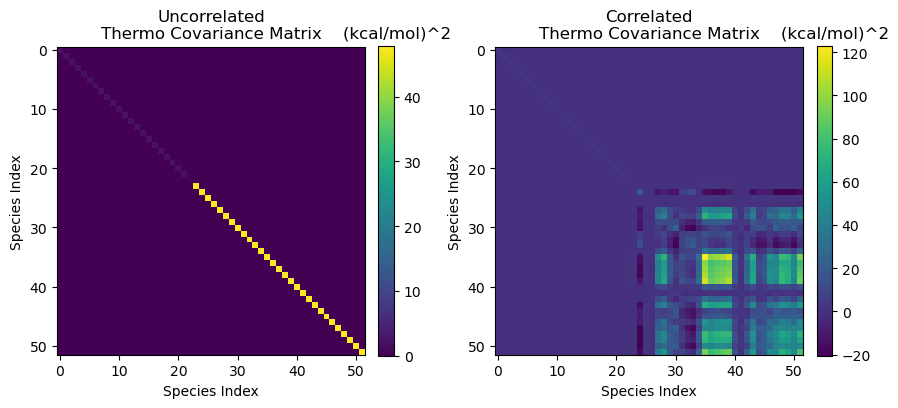

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))
plt.subplots_adjust(wspace=0.3)

# Uncorrelated Species Thermo Uncertainties
mat1 = axs[0].matshow(uncorrelated_thermo_cov)
axs[0].xaxis.set_ticks_position('bottom')
axs[0].xaxis.set_label_position('bottom')
cb1 = fig.colorbar(mat1, ax=axs[0], fraction=0.046, pad=0.04)
cb1.ax.set_title('    (kcal/mol)^2')
axs[0].set_title('Uncorrelated\nThermo Covariance Matrix')
axs[0].set_xlabel('Species Index')
axs[0].set_ylabel('Species Index')

# Correlated Species Thermo Uncertainties
mat2 = axs[1].matshow(correlated_thermo_cov)
axs[1].xaxis.set_ticks_position('bottom')
axs[1].xaxis.set_label_position('bottom')
cb2 = fig.colorbar(mat2, ax=axs[1], fraction=0.046, pad=0.04)
cb2.ax.set_title('    (kcal/mol)^2')
axs[1].set_title('Correlated\nThermo Covariance Matrix')
axs[1].set_xlabel('Species Index')
axs[1].set_ylabel('Species Index')


Text(0, 0.5, 'Reaction Index')

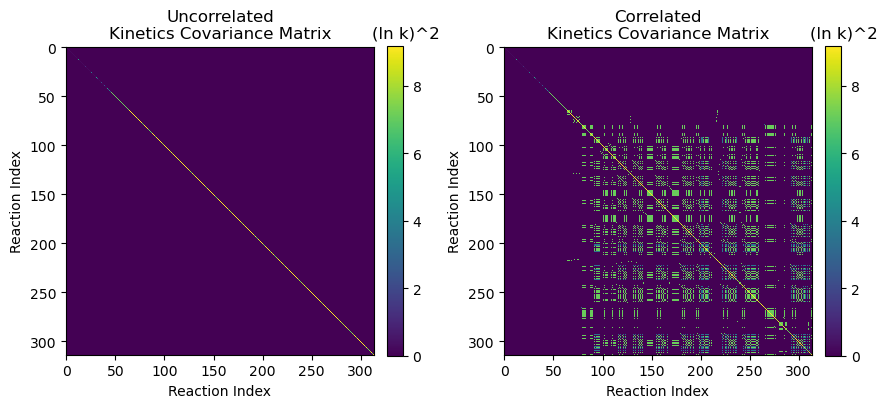

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))
plt.subplots_adjust(wspace=0.3)

# Uncorrelated Species Thermo Uncertainties
mat1 = axs[0].matshow(uncorrelated_kinetics_cov)
axs[0].xaxis.set_ticks_position('bottom')
axs[0].xaxis.set_label_position('bottom')
cb1 = fig.colorbar(mat1, ax=axs[0], fraction=0.046, pad=0.04)
cb1.ax.set_title('    (ln k)^2')
axs[0].set_title('Uncorrelated\nKinetics Covariance Matrix')
axs[0].set_xlabel('Reaction Index')
axs[0].set_ylabel('Reaction Index')

# Correlated Species Thermo Uncertainties
mat2 = axs[1].matshow(correlated_kinetics_cov)
axs[1].xaxis.set_ticks_position('bottom')
axs[1].xaxis.set_label_position('bottom')
cb2 = fig.colorbar(mat2, ax=axs[1], fraction=0.046, pad=0.04)
cb2.ax.set_title('    (ln k)^2')
axs[1].set_title('Correlated\nKinetics Covariance Matrix')
axs[1].set_xlabel('Reaction Index')
axs[1].set_ylabel('Reaction Index')


# 6. Use covariance matrices to run global sampling study outside RMG
### Now that we have the input covariances, we can export our mechanism to other solvers like Cantera and sample accordingly

Note that to keep the code simple, this example uses a well-mixed reactor with a reactive surface, but could be replaced by any of the Cantera examples, including the PFR code here https://cantera.org/dev/examples/python/reactors/surf_pfr_chain.html

Note that the number of parameters should be reduced to only the most important before running a global sampling study (due to computational cost). This demo does not cover nearly enough samples for the distribution to converge and is only meant to show how the parameters could be sampled using a simulator external to RMG.

In [12]:
## Build a simple CSTR surface reactor in Cantera

# convert chemkin to cantera yaml
cantera_file = os.path.join(os.path.dirname(chemkin_file), 'chem_annotated.yaml')
result = subprocess.check_output(['ck2yaml', f'--input={chemkin_file}', f'--surface={surface_chemkin_file}', f'--output={cantera_file}'])

/home/moon/miniforge3/envs/rmg_env/lib/python3.9/site-packages/cantera/ck2yaml.py:2346: UserWarning: StickingRate::validate: 
Sticking coefficient is greater than 1 for reaction 'C2H6(8) + 2 X(1) <=> HX(21) + XCH2CH3(54)'
at T = 10000.0

  phase = Interface(out_name, surf_name, [gas])


/tmp/ipykernel_283727/1579794787.py:3: UserWarning: StickingRate::validate: 
Sticking coefficient is greater than 1 for reaction 'C2H6(8) + 2 X(1) <=> HX(21) + XCH2CH3(54)'
at T = 10000.0

  surf = ct.Interface(cantera_file, "SURF0", [gas])


Text(0, 0.5, 'Mole Fraction (s)')

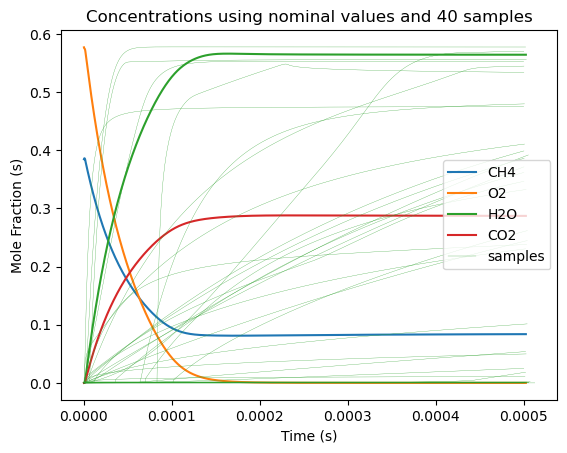

In [13]:
# Run simulation and plot nominal results
gas = ct.Solution(cantera_file)
surf = ct.Interface(cantera_file, "SURF0", [gas])

# Initialize the reactor
gas.TPX = 600, ct.one_atm, 'CH4(2):1, O2(3):1.5, AR:0.1'
surf.TP = 600, ct.one_atm

reactor = ct.IdealGasReactor(gas, energy='off')
upstream = ct.Reservoir(gas, name='upstream')
downstream = ct.Reservoir(gas, name='downstream')
rsurf = ct.ReactorSurface(surf, reactor, A=1e4)

mass_flow_rate = 8e-8
m = ct.MassFlowController(upstream, reactor, mdot=mass_flow_rate)
v = ct.PressureController(reactor, downstream, primary=m, K=1e-5)

sim = ct.ReactorNet([reactor])

times = [0]
gas_concs = [gas.X]
while sim.time < 5e-4:
    sim.step()
    times.append(sim.time)
    gas_concs.append(gas.X)
times = np.array(times)
gas_concs = np.array(gas_concs)

# Plot the nominal values
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.plot(times, gas_concs[:, gas.species_names.index('CH4(2)')], label='CH4', color=colors[0])
plt.plot(times, gas_concs[:, gas.species_names.index('O2(3)')], label='O2', color=colors[1])
plt.plot(times, gas_concs[:, gas.species_names.index('H2O(5)')], label='H2O', color=colors[2])
plt.plot(times, gas_concs[:, gas.species_names.index('CO2(4)')], label='CO2', color=colors[3])


# ---------------------------------- now sample according to the covariance matrix ------------------------------

N_samples = 40
thermo_perturbations = np.random.multivariate_normal(mean=np.zeros(correlated_thermo_cov.shape[0]), cov=correlated_thermo_cov, size=N_samples)
thermo_perturbations *= 4184  # convert kcal/mol to J/mol

kinetic_perturbations = np.random.multivariate_normal(mean=np.zeros(correlated_kinetics_cov.shape[0]), cov=correlated_kinetics_cov, size=N_samples)
kinetic_multipliers = np.exp(kinetic_perturbations)  # convert from lnk to multiplier

def perturb_species(species, DELTA_J_MOL=418.4):
    # takes in a Cantera species and makes a copy with the enthalpy offset changed
    R = 8.3144598  # gas constant in J/mol
    increase = DELTA_J_MOL / R
    # copy the species
    input_data = species.input_data.copy()
    for i in range(len(input_data['thermo']['data'])):
        input_data['thermo']['data'][i][5] += increase
    new_species = ct.Species().from_dict(input_data)
    return new_species

# make copies for faster reset
gas_thermo_copies = []
for i in range(gas.n_species):
    gas_thermo_copies.append(ct.Species().from_dict(gas.species()[i].input_data.copy()))
surface_thermo_copies = []
for i in range(surf.n_species):
    surface_thermo_copies.append(ct.Species().from_dict(surf.species()[i].input_data.copy()))

for i in range(N_samples):
    # perturb all the species according to samples using covariance matrix
    for sp_index in range(gas.n_species):
        perturbed_sp = perturb_species(gas_thermo_copies[sp_index], thermo_perturbations[i, sp_index])
        gas.modify_species(sp_index, perturbed_sp)
    for sp_index in range(surf.n_species):
        perturbed_sp = perturb_species(surface_thermo_copies[sp_index], thermo_perturbations[i, gas.n_species + sp_index])
        surf.modify_species(sp_index, perturbed_sp)

    # perturb all the reaction rates according to samples using covariance matrix
    for rxn_index in range(gas.n_reactions):
        gas.set_multiplier(kinetic_multipliers[i, rxn_index], rxn_index)
    for rxn_index in range(surf.n_reactions):
        surf.set_multiplier(kinetic_multipliers[i, gas.n_reactions + rxn_index], rxn_index)

    # rerun the simulation and plot the sampled results
    gas.TPX = 600, ct.one_atm, 'CH4(2):1, O2(3):1.5, AR:0.1'
    surf.TP = 600, ct.one_atm
    
    reactor = ct.IdealGasReactor(gas, energy='off')
    upstream = ct.Reservoir(gas, name='upstream')
    downstream = ct.Reservoir(gas, name='downstream')
    rsurf = ct.ReactorSurface(surf, reactor, A=1e4)

    m = ct.MassFlowController(upstream, reactor, mdot=mass_flow_rate)
    v = ct.PressureController(reactor, downstream, primary=m, K=1e-5)
    sim = ct.ReactorNet([reactor])
    
    times_perturbed = [0]
    gas_concs_perturbed = [gas.X]
    while sim.time < 5e-4:
        sim.step()
        times_perturbed.append(sim.time)
        gas_concs_perturbed.append(gas.X)
    times_perturbed = np.array(times_perturbed)
    gas_concs_perturbed = np.array(gas_concs_perturbed)

    if i > 0:
        label = '_no_label'
    else:
        label = 'samples'
    # plt.plot(times_perturbed, gas_concs_perturbed[:, gas.species_names.index('CH4(2)')], label='_no_label', color=colors[0], linewidth=0.2)
    # plt.plot(times_perturbed, gas_concs_perturbed[:, gas.species_names.index('O2(3)')], label='_no_label', color=colors[1], linewidth=0.2)
    plt.plot(times_perturbed, gas_concs_perturbed[:, gas.species_names.index('H2O(5)')], label=label, color=colors[2], linewidth=0.2)
    # plt.plot(times_perturbed, gas_concs_perturbed[:, gas.species_names.index('CO2(4)')], label='_no_label', color=colors[3], linewidth=0.2)

    # Reset things
    for sp_index in range(surf.n_species):
        surf.modify_species(sp_index, surface_thermo_copies[sp_index])
    for sp_index in range(gas.n_species):
        gas.modify_species(sp_index, gas_thermo_copies[sp_index])
    surf.set_multiplier(1.0)
    gas.set_multiplier(1.0)

plt.legend()
plt.title(f'Concentrations using nominal values and {N_samples} samples')
plt.xlabel('Time (s)')
plt.ylabel('Mole Fraction (s)')
